In [18]:
# Библиотеки за манипулација со податоци
import pandas as pd
import numpy as np

# Библиотеки за визуелизација
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки за претпроцесирање
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Библиотеки за модел и евалуација
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    LassoCV,
    RidgeCV,
    LogisticRegression,
)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [2]:
# Вчитување на податочното множество
df = pd.read_csv('vacation_preferences_data.csv')

# Приказ на првите 5 редици
print("Првите 5 редици од податоците:")
df.head()

Првите 5 редици од податоците:


,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56.0,male,71477,bachelor,9,skiing,2477,urban,175.0,267,summer,0,1,1
1,69.0,male,88740,master,1,swimming,4777,suburban,NaN,190,fall,0,1,0
2,46.0,female,46562,master,0,skiing,1469,urban,71.0,280,winter,0,0,1
3,32.0,non-binary,99044,high school,6,hiking,1482,rural,31.0,255,summer,1,0,1
4,60.0,female,106583,high school,5,sunbathing,516,suburban,23.0,151,winter,1,1,0


In [3]:
# Приказ на информации за секоја колона
print("Информации за податочното множество:")
df.info()

print("\nОписна статистика за нумеричките колони:")
print(df.describe())

print("\nОписна статистика за категориските колони:")
print(df.describe(include='object'))

Информации за податочното множество:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52444 entries, 0 to 52443
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     47200 non-null  float64
 1   Gender                  52444 non-null  object 
 2   Income                  52444 non-null  int64  
 3   Education_Level         49822 non-null  object 
 4   Travel_Frequency        52444 non-null  int64  
 5   Preferred_Activities    52444 non-null  object 
 6   Vacation_Budget         52444 non-null  int64  
 7   Location                52444 non-null  object 
 8   Proximity_to_Mountains  49822 non-null  float64
 9   Proximity_to_Beaches    52444 non-null  int64  
 10  Favorite_Season         52444 non-null  object 
 11  Pets                    52444 non-null  int64  
 12  Environmental_Concerns  52444 non-null  int64  
 13  Preference              52444 non-null  int64  
dtypes

In [4]:
# Пресметка на вкупниот број на NaN вредности по колона
missing_values = df.isnull().sum()
print("Вредности што недостасуваат по колони:")
print(missing_values[missing_values > 0])

Вредности што недостасуваат по колони:
Age                       5244
Education_Level           2622
Proximity_to_Mountains    2622
dtype: int64


Дистрибуција на преференци:
Preference
0    0.749294
1    0.250706
Name: proportion, dtype: float64


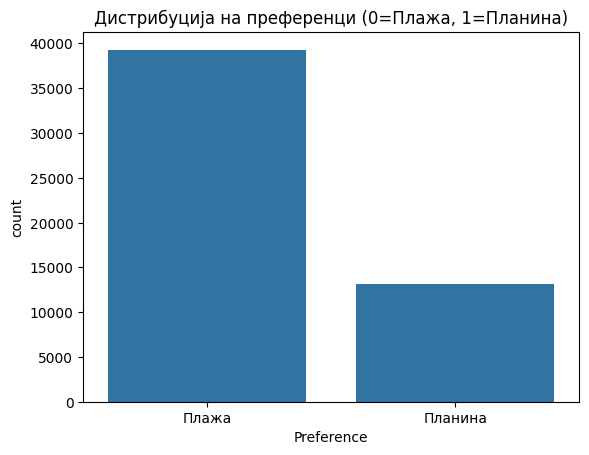

In [5]:
# Дистрибуција на целната променлива 'Preference'
print("Дистрибуција на преференци:")
# normalize=True ни дава проценти
print(df['Preference'].value_counts(normalize=True))

# Визуелизација на дистрибуцијата
sns.countplot(x='Preference', data=df)
plt.title('Дистрибуција на преференци (0=Плажа, 1=Планина)')
plt.xticks([0, 1], ['Плажа', 'Планина'])
plt.show()

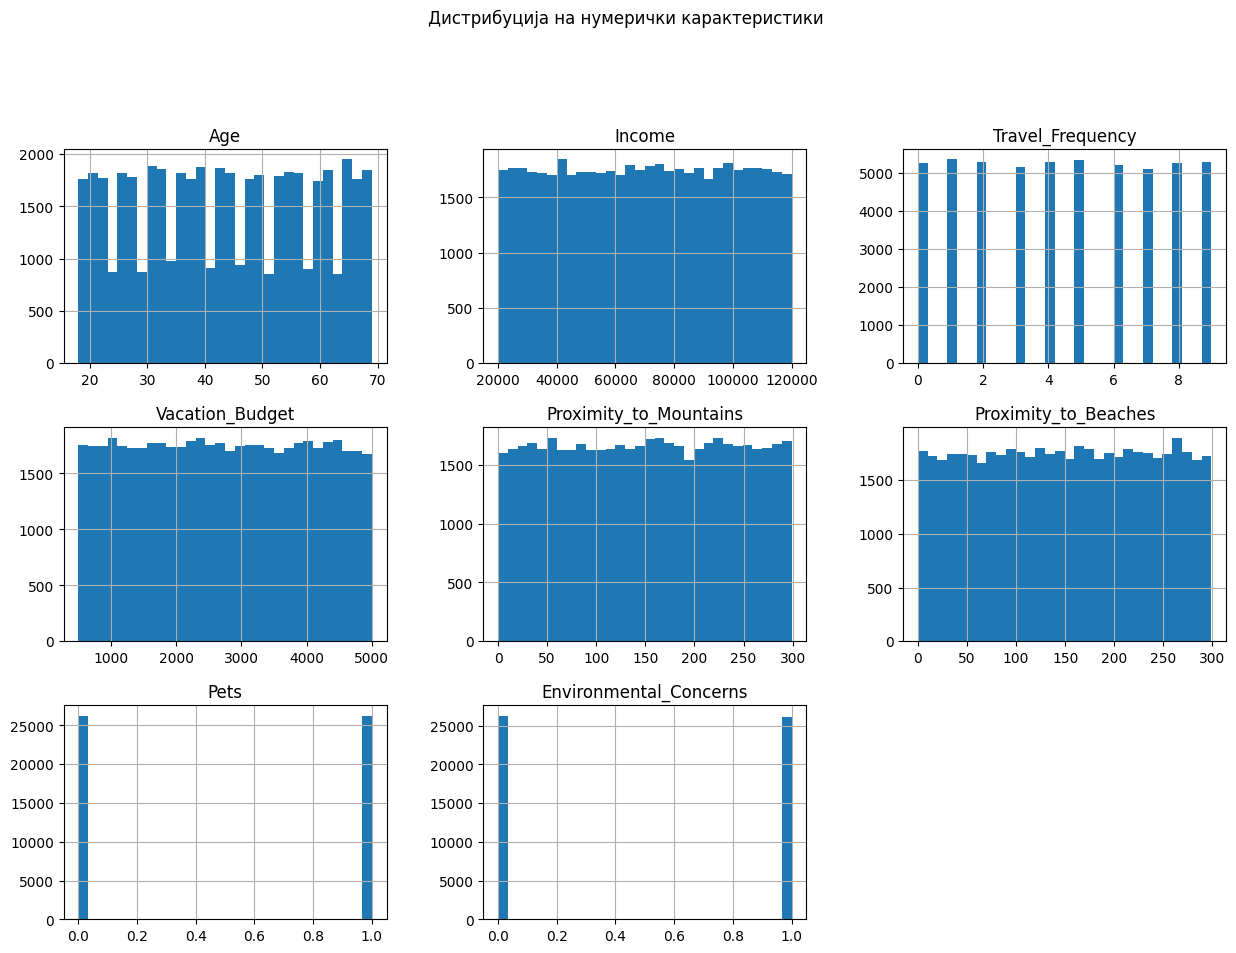

In [6]:
# Избор на нумерички колони
numeric_cols = df.select_dtypes(include=np.number).drop('Preference', axis=1).columns

# Креирање хистограми за нумеричките колони
df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Дистрибуција на нумерички карактеристики', y=1.02)
plt.show()

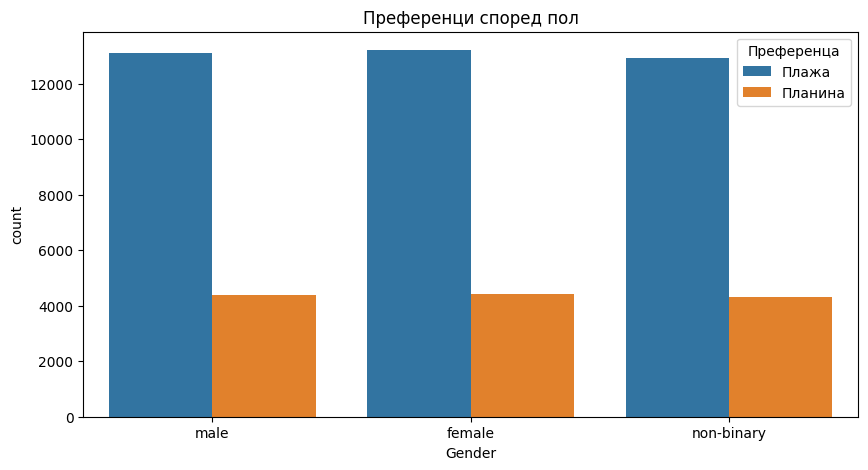

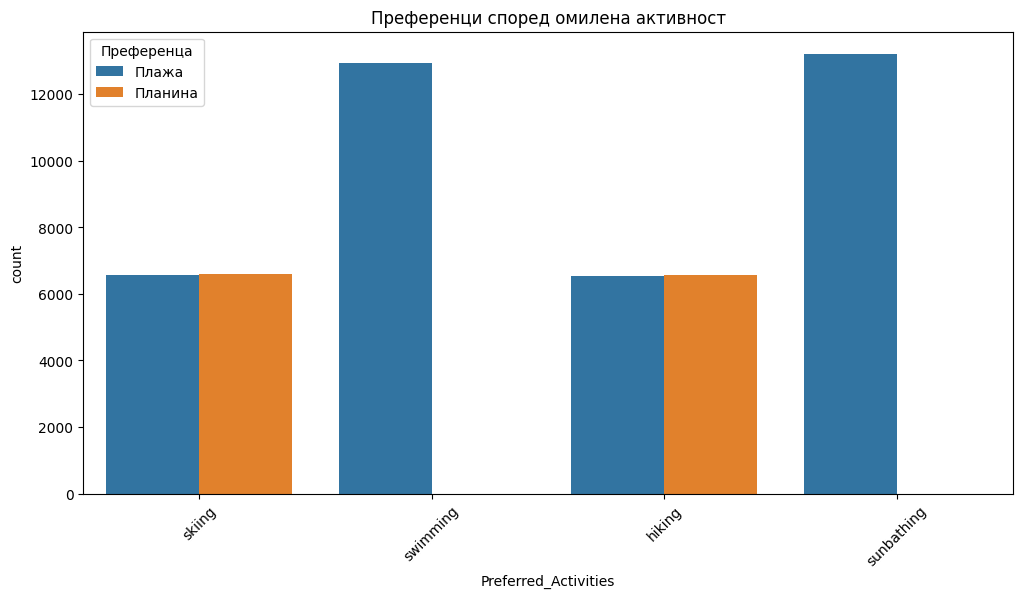

In [7]:
# Врска помеѓу 'Gender' и 'Preference'
plt.figure(figsize=(10, 5))
sns.countplot(x='Gender', hue='Preference', data=df)
plt.title('Преференци според пол')
plt.legend(title='Преференца', labels=['Плажа', 'Планина'])
plt.show()

# Врска помеѓу 'Preferred_Activities' и 'Preference'
plt.figure(figsize=(12, 6))
sns.countplot(x='Preferred_Activities', hue='Preference', data=df)
plt.title('Преференци според омилена активност')
plt.xticks(rotation=45)
plt.legend(title='Преференца', labels=['Плажа', 'Планина'])
plt.show()

In [8]:
# Дефинирање на карактеристики (X) и целна променлива (y)
X = df.drop('Preference', axis=1)
y = df['Preference']

# Целната променлива 'y' е веќе нумеричка (0 и 1), 
# така што не ни е потребен LabelEncoder за неа.

print("Големина на X (карактеристики):", X.shape)
print("Големина на y (целна променлива):", y.shape)

Големина на X (карактеристики): (52444, 13)
Големина на y (целна променлива): (52444,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Осигурува иста дистрибуција на класи во двата сета
)

print("Големина на сет за обука:", X_train.shape)
print("Големина на сет за тестирање:", X_test.shape)

Големина на сет за обука: (41955, 13)
Големина на сет за тестирање: (10489, 13)


In [10]:
# Идентификација на имињата на колоните според тип
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

print("Нумерички карактеристики:", list(numeric_features))
print("Категориски карактеристики:", list(categorical_features))

Нумерички карактеристики: ['Age', 'Income', 'Travel_Frequency', 'Vacation_Budget', 'Proximity_to_Mountains', 'Proximity_to_Beaches', 'Pets', 'Environmental_Concerns']
Категориски карактеристики: ['Gender', 'Education_Level', 'Preferred_Activities', 'Location', 'Favorite_Season']


In [11]:
# --- 1. Imputer за нумерички колони (стратегија 'median') ---
num_imputer = SimpleImputer(strategy='median')

# Прво правиме .fit_transform() на X_train
X_train_numeric_imputed = num_imputer.fit_transform(X_train[numeric_features])
# Потоа само .transform() на X_test
X_test_numeric_imputed = num_imputer.transform(X_test[numeric_features])

# --- 2. Imputer за категориски колони (стратегија 'most_frequent') ---
cat_imputer = SimpleImputer(strategy='most_frequent')

# Прво правиме .fit_transform() на X_train
X_train_cat_imputed = cat_imputer.fit_transform(X_train[categorical_features])
# Потоа само .transform() на X_test
X_test_cat_imputed = cat_imputer.transform(X_test[categorical_features])

print("Нумеричките и категориските податоци се пополнети (imputed).")

Нумеричките и категориските податоци се пополнети (imputed).


In [12]:
# Иницијализација на OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# .fit_transform() на податоците за обука
X_train_encoded = encoder.fit_transform(X_train_cat_imputed)
# .transform() на податоците за тестирање
X_test_encoded = encoder.transform(X_test_cat_imputed)

# Добивање на имињата на новите колони од енкодерот
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

# Конвертирање на енкодираните низи во DataFrame
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

print("Категориските карактеристики се енкодирани.")
print("Нова големина на енкодирани податоци за обука:", X_train_encoded_df.shape)

Категориските карактеристики се енкодирани.
Нова големина на енкодирани податоци за обука: (41955, 18)


In [13]:
# Иницијализација на StandardScaler
scaler = StandardScaler()

# .fit_transform() на податоците за обука
X_train_scaled = scaler.fit_transform(X_train_numeric_imputed)
# .transform() на податоците за тестирање
X_test_scaled = scaler.transform(X_test_numeric_imputed)

# Конвертирање на скалираните низи во DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_features, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_features, index=X_test.index)

print("Нумеричките карактеристики се скалирани.")
X_train_scaled_df.head()

Нумеричките карактеристики се скалирани.


,Age,Income,Travel_Frequency,Vacation_Budget,Proximity_to_Mountains,Proximity_to_Beaches,Pets,Environmental_Concerns
29827,-1.792659,0.051251,-1.554597,-1.387448,1.090887,1.270154,1.000787,0.996360
40662,1.163209,0.537643,0.878933,1.183821,-0.876922,-0.105311,-0.999214,-1.003653
14973,0.177920,1.464563,-0.859303,1.075078,1.683600,-0.521417,1.000787,-1.003653
36701,0.177920,0.276385,-0.164009,-1.179988,-0.497585,-0.278688,-0.999214,-1.003653
26540,-1.159259,-1.581683,0.531286,0.652446,0.012148,1.489766,1.000787,0.996360


In [14]:
# Спојување (concat) на скалираните нумерички и енкодираните категориски колони
X_train_processed = pd.concat([X_train_scaled_df, X_train_encoded_df], axis=1)
X_test_processed = pd.concat([X_test_scaled_df, X_test_encoded_df], axis=1)

print("Финални податоци за обука (X_train_processed):", X_train_processed.shape)
print("Финални податоци за тест (X_test_processed):", X_test_processed.shape)
X_train_processed.head()

Финални податоци за обука (X_train_processed): (41955, 26)
Финални податоци за тест (X_test_processed): (10489, 26)


,Age,Income,Travel_Frequency,Vacation_Budget,Proximity_to_Mountains,Proximity_to_Beaches,Pets,Environmental_Concerns,Gender_female,Gender_male,...,Preferred_Activities_skiing,Preferred_Activities_sunbathing,Preferred_Activities_swimming,Location_rural,Location_suburban,Location_urban,Favorite_Season_fall,Favorite_Season_spring,Favorite_Season_summer,Favorite_Season_winter
29827,-1.792659,0.051251,-1.554597,-1.387448,1.090887,1.270154,1.000787,0.996360,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
40662,1.163209,0.537643,0.878933,1.183821,-0.876922,-0.105311,-0.999214,-1.003653,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
14973,0.177920,1.464563,-0.859303,1.075078,1.683600,-0.521417,1.000787,-1.003653,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
36701,0.177920,0.276385,-0.164009,-1.179988,-0.497585,-0.278688,-0.999214,-1.003653,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
26540,-1.159259,-1.581683,0.531286,0.652446,0.012148,1.489766,1.000787,0.996360,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [15]:
# Дефинирање на моделот (класификатор)
# max_iter=1000 се додава за да се осигура дека моделот ќе конвергира
classifier = LogisticRegression(random_state=42, max_iter=1000)

# Тренирање на моделот
print("Започнувам со тренирање на моделот...")
classifier.fit(X_train_processed, y_train)

print("Моделот е успешно истрениран.")

Започнувам со тренирање на моделот...
Моделот е успешно истрениран.


In [16]:
# Генерирање предвидувања врз тест податоците
y_pred = classifier.predict(X_test_processed)

print("Првите 10 предвидувања:", y_pred[:10])
print("Првите 10 вистински вредности:", y_test.values[:10])

Првите 10 предвидувања: [0 0 1 0 0 0 0 0 0 0]
Првите 10 вистински вредности: [0 0 1 0 0 0 0 0 0 0]


Точност (Accuracy): 99.01%

Classification Report:
                         precision    recall  f1-score   support

  Преференца: Плажа (0)       0.99      0.99      0.99      7859
Преференца: Планина (1)       0.98      0.98      0.98      2630

               accuracy                           0.99     10489
              macro avg       0.99      0.99      0.99     10489
           weighted avg       0.99      0.99      0.99     10489


Confusion Matrix:


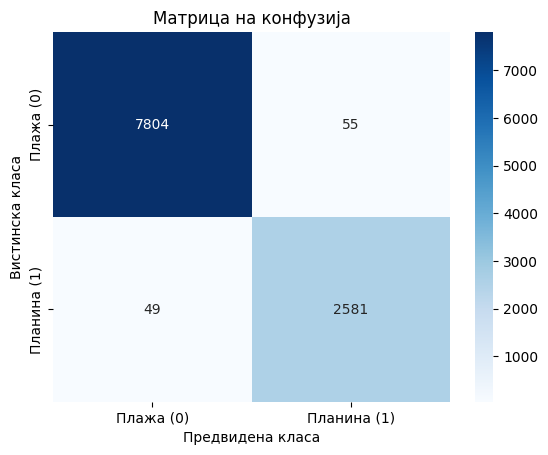

In [17]:
# 1. Пресметка на точност (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точност (Accuracy): {accuracy * 100:.2f}%")

# 2. Приказ на детален извештај (Classification Report)
# Дефинираме имиња на класи (0 = Плажа, 1 = Планина)
target_names = ['Преференца: Плажа (0)', 'Преференца: Планина (1)']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3. Приказ на матрица на конфузија (Confusion Matrix)
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# Визуелизација на матрицата на конфузија
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Плажа (0)', 'Планина (1)'], 
            yticklabels=['Плажа (0)', 'Планина (1)'])
plt.xlabel('Предвидена класа')
plt.ylabel('Вистинска класа')
plt.title('Матрица на конфузија')
plt.show()

In [20]:
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MAE: 0.009915149203927925
MAPE: 23615023310647.09
MSE: 0.009915149203927925
RMSE: 0.09957484222396702
R2 Score: 0.9472230379836248
